# Self-Supervised Contrastive Learning: From Triplet Loss to SimCLR

**Course**: CSC 383 / 483 – Applied Deep Learning

**Description**:
In this assignment, you will investigate **Self-Supervised Contrastive Learning (SSCL)** by implementing the core components of the **SimCLR** framework. Traditional supervised learning requires massive datasets with manual labels. To overcome this, you will build a model that learns visual representations directly from unlabeled images (CIFAR-10) by maximizing the agreement between differently augmented views of the same image. Finally, you will compare the modern NT-Xent loss with the traditional Triplet Loss to understand why contrastive learning is so effective.

## Learning Objectives

By the end of this assignment, you will be able to:

- Build a **self-supervised** contrastive learning pipeline that learns from **unlabeled images**.
- Implement and compare two contrastive objectives: **Triplet Loss** and **NT‑Xent (InfoNCE, SimCLR-style)**.
- Train an encoder with **strong augmentations** and a **non-linear projection head**.
- Evaluate learned representations using **Top‑K retrieval** and **linear probe** downstream evaluation.

**Estimated time:** ~2–3 hours on Colab (GPU recommended but not required).  
**Framework constraint:** **TensorFlow / Keras only** (no PyTorch).


## Background: The SimCLR Pipeline (How to Learn without Labels)

Traditional supervised learning is straightforward (Input -> Model -> Label). However, contrastive learning requires us to dynamically generate our own targets. Here is the step-by-step pipeline of how our model learns without labels.

**Step 1: Two Augmented Views (Splitting and Duplicating Data))**
We pass the original batch of N images through our augmentation pipeline _twice_ to create **Batch A** and **Batch B**.

- **Positive Pair:** A1 and B1 come from the same original image, so they must be pulled together.
- **Negative Pair:** A1 and B2 (where elements are from different images) must be pushed apart.

**Step 2: Feature Extraction (Passing through Encoder & Extracting Embeddings)**
We pass both Batch A and Batch B through our shared MobileNetV2 encoder to extract the core meaning of the images into dense number vectors (Embeddings). We get `z_a` and `z_b`. We also L2-normalize them.

**Step 3: N×N Similarity Matrix (Constructing the Similarity Matrix)**
By performing a matrix multiplication (`tf.matmul`) between `z_a` and `z_b`, we create a massive N×N comparison grid.

|         |    B1     |    B2     |    B3     |   ...   |    BN     |
| :-----: | :-------: | :-------: | :-------: | :-----: | :-------: |
| **A1**  | **[Pos]** |   [Neg]   |   [Neg]   |   ...   |   [Neg]   |
| **A2**  |   [Neg]   | **[Pos]** |   [Neg]   |   ...   |   [Neg]   |
| **A3**  |   [Neg]   |   [Neg]   | **[Pos]** |   ...   |   [Neg]   |
| **...** |    ...    |    ...    |    ...    | **...** |    ...    |
| **AN**  |   [Neg]   |   [Neg]   |   [Neg]   |   ...   | **[Pos]** |

- **Diagonal (Positive):** Match. The model should maximize these scores.
- **Off-Diagonal (Negative):** Mismatch. The model should minimize these scores.

**Step 4: The NT-Xent Loss (128-Choice Multiple Choice Problem)**
We treat this N×N matrix as a **N-choice multiple-choice question**.

```text
"Among the 128 images in Batch B, which one is the augmented pair of A?"

A1   ──>  ( B1 ✓ )    ( B2 ✗ )    ( B3 ✗ )  ...  ( BN ✗ )
A2   ──>  ( B1 ✗ )    ( B2 ✓ )    ( B3 ✗ )  ...  ( BN ✗ )
For any row i, the correct answer is exactly the column i.
By applying standard CategoricalCrossentropy where the labels are the diagonal (0, 1, 2... N-1),
the model naturally learns to push negatives away and pull positives closer.
```

**Step 5: Custom train_step Overriding** Instead of creating fake dummy labels to force `model.fit()` to work, we will subclass `keras.Model` and override the `train_step` method. This is a standard industry practice for training advanced self-supervised models.

**Why compare Triplet (margin-based) vs NT-Xent (InfoNCE)?**
In the SimCLR paper (Chen et al., 2020, https://arxiv.org/abs/2002.05709), the authors report that **NT-Xent** substantially outperforms several **margin-based alternatives** under the linear evaluation protocol (Table 4), motivating this assignment’s comparison. (In their setting, a representative margin-based loss achieves **50.9%** top-1 linear evaluation accuracy, while **NT-Xent** reaches **63.9%**.)


## Setup

We will first import some useful libraries:

- `tensorflow` / `keras`: for building and training deep learning models.
- `keras.layers`: provides the building blocks (dense layers, convolutional layers, activation functions, etc.) to design neural networks.
- `matplotlib`: for visualizing images and plotting graphs.
- `numpy`: for numerical operations and array manipulation


In [ ]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import matplotlib.pyplot as plt
import numpy as np
import os

# Reproducibility (keep small; exact numbers may still vary on GPU)
SEED = 42
keras.utils.set_random_seed(SEED)

# Using GPU (optional)
print("GPUs:", tf.config.list_physical_devices("GPU"))

# =====================================================
# Global Configuration (tuned for 2–3 hour completion)
# =====================================================
TRAIN_SAMPLES = 20000  # use a subset for faster SSL training
BATCH_SIZE = 256  # SimCLR benefits from larger batches; reduce if OOM
EPOCHS = 3  # keep small to stay within time constraints
LEARNING_RATE = 1e-3

TEMPERATURE = 0.5  # τ for NT-Xent
MARGIN = 0.5  # α for Triplet Loss
EMBEDDING_DIM = 128  # projection head output dim

# Linear probe (downstream evaluation)
PROBE_TRAIN_SAMPLES = 10000
PROBE_TEST_SAMPLES = 5000
PROBE_EPOCHS = 20
PROBE_LR = 1e-3

AUTOTUNE = tf.data.AUTOTUNE

GPUs: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


## Prepare the Data [0/0]

**[Course Ref: HW01 / HW02 - Data Preparation]**

To ensure this assignment can be completed within the 2-3 hour timeframe on a standard Colab GPU, we will use the **CIFAR-10** dataset. CIFAR-10 contains 60,000 32x32 color images in 10 different classes: airplane, automobile, bird, cat, deer, dog, frog, horse, ship, truck

We provide the starter code to load and normalize the dataset. Because Contrastive Learning is self-supervised, we do not need the training labels (y_train) for the pre-training phase. Therefore, we only feed the raw images into our tf.data.Dataset pipeline, sliced to TRAIN_SAMPLES to keep runtime manageable on Colab. The dataset is shuffled, batched, and prefetched so the GPU stays fully utilized. However, we load the test labels (y_test) to evaluate our learned embeddings later in Part 5.

We also prepare a separate labeled subset (`x_probe`, `y_probe`) for **linear probe** evaluation in Part 5. Since the encoder trains without any labels, this allows us to later measure the quality of the learned embeddings by training a simple classifier on top of the frozen encoder.


In [ ]:
# Load CIFAR-10 dataset
(x_train_full, y_train_full), (x_test_full, y_test_full) = (
    keras.datasets.cifar10.load_data()
)

# Normalize pixel values to [0, 1]
x_train_full = x_train_full.astype("float32") / 255.0
x_test_full = x_test_full.astype("float32") / 255.0

y_train_full = y_train_full.astype("int64").squeeze()
y_test_full = y_test_full.astype("int64").squeeze()

print(
    "x_train_full shape:", x_train_full.shape, "y_train_full shape:", y_train_full.shape
)
print("x_test_full shape:", x_test_full.shape, "y_test_full shape:", y_test_full.shape)

# ------------------------------------------------
# Self-supervised pretraining dataset (NO labels)
# ------------------------------------------------
ssl_x = x_train_full[:TRAIN_SAMPLES]
train_dataset = tf.data.Dataset.from_tensor_slices(ssl_x)
train_dataset = (
    train_dataset.shuffle(10_000, seed=SEED).batch(BATCH_SIZE).prefetch(AUTOTUNE)
)

# -----------------------------------------------------------
# Downstream evaluation (linear probe) uses labels
# NOTE: This is a standard SimCLR-style evaluation protocol:
# freeze embeddings, train a linear classifier on top.
# -----------------------------------------------------------
x_probe_train = x_train_full[:PROBE_TRAIN_SAMPLES]
y_probe_train = y_train_full[:PROBE_TRAIN_SAMPLES]

x_probe_test = x_test_full[:PROBE_TEST_SAMPLES]
y_probe_test = y_test_full[:PROBE_TEST_SAMPLES]

print("Probe train:", x_probe_train.shape, y_probe_train.shape)
print("Probe test :", x_probe_test.shape, y_probe_test.shape)

# Backward-compatible aliases
x_test = x_test_full
y_test = y_test_full

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 6s 0us/step
x_train_full shape: (50000, 32, 32, 3) y_train_full shape: (50000,)
x_test_full shape: (10000, 32, 32, 3) y_test_full shape: (10000,)
Probe train: (10000, 32, 32, 3) (10000,)
Probe test : (5000, 32, 32, 3) (5000,)


## Part 1: Strong Augmentation [10 pts]

**[Course Ref: WEEK_06: Data Augmentation]**  
**[Course Ref: WEEK_04: Generalization]**  
**[Paper Ref: SimCLR Section 3 - Composition of data augmentations is crucial]**

According to the SimCLR paper, a simple random crop is not enough. The neural network will use the color distribution as a "shortcut" to solve the contrastive task. We must compose multiple strong augmentations to prevent overfitting and improve **generalization**.

**Task (20 pts):** Build `data_augmentation` as a `keras.Sequential` pipeline that includes:

- `layers.Resizing` (to slightly larger, e.g., 36x36)
- `layers.RandomCrop` (back to 32x32)
- `layers.RandomFlip` ("horizontal")
- A custom color distortion (`RandomColorDistortion` layer provided below).


In [ ]:
## Part 1: Data Augmentation Pipeline [20 pts]


# Starter Code: Custom Color Jitter Layer
class RandomColorDistortion(layers.Layer):
    def call(self, images):
        x = tf.image.random_brightness(images, max_delta=0.2)
        x = tf.image.random_contrast(x, lower=0.8, upper=1.2)
        return x


# ==========================================================
# Solution 1: Build the data augmentation pipeline [20 pts]
# ==========================================================
data_augmentation = keras.Sequential(
    [
        layers.Resizing(36, 36),
        layers.RandomCrop(32, 32),
        layers.RandomFlip("horizontal"),
        RandomColorDistortion(),
    ]
)

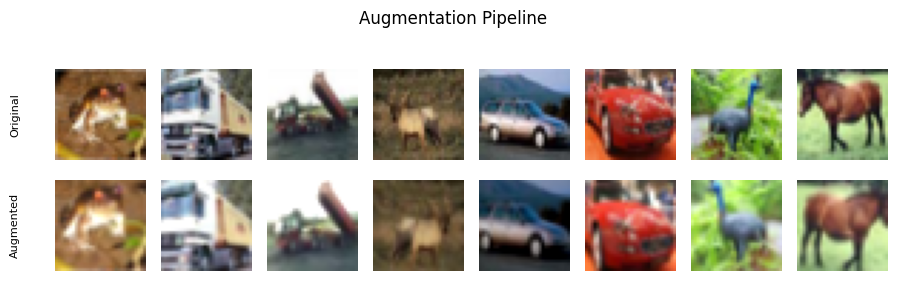

In [ ]:
# Quick visual check
sample = x_train_full[:8]
fig, axes = plt.subplots(2, 8, figsize=(9, 3))
for i in range(8):
    # ----- Original image -----
    axes[0, i].imshow(np.clip(sample[i], 0, 1))
    axes[0, i].axis("off")
    # ----- Augmented image -----
    aug_img = data_augmentation(sample[i : i + 1], training=True)[0].numpy()
    axes[1, i].imshow(np.clip(aug_img, 0, 1))
    axes[1, i].axis("off")

# Labels
axes[0, 0].text(
    -0.5,
    0.5,
    "Original",
    transform=axes[0, 0].transAxes,
    fontsize=8,
    rotation=90,
    va="center",
)

axes[1, 0].text(
    -0.5,
    0.5,
    "Augmented",
    transform=axes[1, 0].transAxes,
    fontsize=8,
    rotation=90,
    va="center",
)

# Title
plt.suptitle("Augmentation Pipeline")

plt.tight_layout()
plt.show()

## Part 2: Base Encoder & Non-linear Projection Head [20 pts]

**[Course Ref: WEEK_06: Transfer Learning]**  
**[Course Ref: WEEK_01: Multilayer Perceptrons]**  
**[Paper Ref: SimCLR Section 4.2 - A nonlinear projection head improves representation quality]**

Instead of building a CNN from scratch, we will use **Transfer Learning** with a pretrained **MobileNetV2** backbone (ImageNet weights).

**Task (20 pts):** Complete the `build_simclr_model` function to satisfy the following constraints:

- **Adapt** CIFAR-10 inputs: Resize to 96x96 and apply MobileNetV2's preprocessing (Hint: `keras.applications.mobilenet_v2.preprocess_input` expects pixels in `[1]`).
- **2.1 Freeze** the base model weights so they are not updated during training **[5 pts]**.
- **2.2 Build the projection head** on top of the base model features **[15 pts]**:
  - `GlobalAveragePooling2D`
  - `Dense` layer with 256 units and `"relu"` activation.
  - A final `Dense` layer outputting a vector of size `EMBEDDING_DIM` (no activation).


In [ ]:
## Part 2: Base Encoder & Non-linear Projection Head [20 pts]


def build_simclr_model():
    # MobileNetV2 requires a minimum image size of 32x32, but 96x96 is recommended for better feature extraction.
    base_model = keras.applications.MobileNetV2(
        input_shape=(96, 96, 3), include_top=False, weights="imagenet"
    )

    # ====================================================================================================
    # Solution 2.1: Freeze MobileNetV2 backbone [5 pts]
    # - Set the `trainable` attribute of the base model to False.
    # ====================================================================================================
    base_model.trainable = False

    inputs = keras.Input(shape=(32, 32, 3))
    x = layers.Resizing(96, 96)(inputs)

    # MobileNetV2 was pretrained with a specific input scaling; adapt CIFAR-10 accordingly
    x = layers.Lambda(
        lambda t: keras.applications.mobilenet_v2.preprocess_input(t * 255.0)
    )(x)

    x = base_model(x, training=False)

    # ====================================================================================================
    # Solution 2.2: Pooling + projection head (non-linear) [15 pts]
    # - Apply `GlobalAveragePooling2D`.
    # - Add a `Dense` layer with 256 units and ReLU activation.
    # - Add a final `Dense` layer to output `EMBEDDING_DIM` (no activation).
    # ====================================================================================================
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dense(256, activation="relu")(x)
    outputs = layers.Dense(EMBEDDING_DIM)(x)

    return keras.Model(inputs, outputs)


model = build_simclr_model()
model.summary()

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)      │ (None, 32, 32, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ resizing_1 (Resizing)           │ (None, 96, 96, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lambda (Lambda)                 │ (None, 96, 96, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_96             │ (None, 3, 3, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       327,936 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        32,896 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,618,816 (9.99 MB)

 Trainable params: 360,832 (1.38 MB)

 Non-trainable params: 2,257,984 (8.61 MB)

## Part 3: Implementing Custom Loss Functions [30 pts]

Here is the core of contrastive learning. We will implement two different loss functions and compare them.

### 3.1 Triplet Loss Model [10 pts]

**[Course Ref: WEEK_06: Siamese Networks & Triplet Loss]**

The traditional approach to learning representations is using the Triplet Loss.
Formula: $L = \max(\|a-p\|^2 - \|a-n\|^2 + \alpha, 0)$

**Task (10 pts):** Complete the `train_step` of the `TripletModel` to calculate the loss.

- In the provided `train_step`, we use `tf.roll` to shift the positive embeddings (`z_b`) by one to act as our negative samples (`z_neg`). This is a simple and efficient way to perform in-batch negative sampling.
- **Compute** `distance_pos`: the squared Euclidean distance between anchor (`z_a`) and positive (`z_b`). (Hint: use `tf.square` and `tf.reduce_sum`)
- **Compute** `distance_neg`: the squared Euclidean distance between anchor (`z_a`) and negative (`z_neg`).
- **Compute** `loss`: use `tf.maximum` to apply the margin, then take the mean of the batch using `tf.reduce_mean`.


In [ ]:
# ======================================
# [Starter Code] 3.1 Triplet Loss Model
# ======================================
class TripletModel(keras.Model):
    def __init__(self, encoder, augment_pipeline, margin=MARGIN):
        super().__init__()
        self.encoder = encoder
        self.augment = augment_pipeline
        self.margin = margin
        self.loss_tracker = keras.metrics.Mean(name="loss")

    @property
    def metrics(self):
        return [self.loss_tracker]

    def train_step(self, data):
        images = data
        aug_a = self.augment(images)  # Anchor
        aug_b = self.augment(images)  # Positive

        with tf.GradientTape() as tape:
            z_a = tf.math.l2_normalize(self.encoder(aug_a, training=True), axis=1)
            z_b = tf.math.l2_normalize(self.encoder(aug_b, training=True), axis=1)

            # Shift z_b by one to create negative samples (Simple in-batch negative sampling)
            z_neg = tf.roll(z_b, shift=1, axis=0)

            # ================================================================================================================
            # Solution 3.1: Calculate Triplet Loss [10 pts]
            # 1. Compute `distance_pos`: the squared Euclidean distance between anchor (z_a) and positive (z_b).
            # 2. Compute `distance_neg`: the squared Euclidean distance between anchor (z_a) and negative (z_neg).
            # 3. Compute `loss`: use `tf.maximum` to apply the margin, then take the mean of the batch using `tf.reduce_mean`.
            # Hint: Use `tf.square` and `tf.reduce_sum(..., axis=1)`.
            # =================================================================================================================
            distance_pos = tf.reduce_sum(tf.square(z_a - z_b), axis=1)
            distance_neg = tf.reduce_sum(tf.square(z_a - z_neg), axis=1)
            loss = tf.maximum(distance_pos - distance_neg + self.margin, 0.0)
            loss = tf.reduce_mean(loss)

        grads = tape.gradient(loss, self.encoder.trainable_variables)
        self.optimizer.apply_gradients(zip(grads, self.encoder.trainable_variables))
        self.loss_tracker.update_state(loss)
        return {"loss": self.loss_tracker.result()}

### 3.2 NT-Xent Loss (SimCLR) [20 pts]

**[Course Ref: HW05: Word Embeddings (Cosine Similarity)]**  
**[Paper Ref: SimCLR Section 5.1 - Normalized cross entropy loss with adjustable temperature]**

SimCLR replaces the hard margin of Triplet Loss with a cosine-similarity-based softmax approach scaled by a temperature $\tau$.

**Task (20 pts):** Complete the `train_step` of the `SimCLRModel` to calculate the NT-Xent loss.

- **1. Feature Extraction & L2 Normalization:** Pass `aug_a` and `aug_b` through `self.encoder` (`training=True`) and L2-normalize to get `z_a` and `z_b`.
- **2. Similarity Matrices (Logits):** Compute similarity for both directions using matrix multiplication `tf.matmul`:
  - `logits_ab` = $z_a \cdot z_b^T / \text{temperature}$ (A as anchor, B as candidates)
  - `logits_ba` = $z_b \cdot z_a^T / \text{temperature}$ (B as anchor, A as candidates)
- **3. NT-Xent Loss:**
  - Get the `batch_size` and set the correct matches as the diagonal indices (`tf.range`).
  - Compute `sparse_categorical_crossentropy` (with `from_logits=True`) for both directions (`loss_ab`, `loss_ba`).
  - Calculate the final `loss` by taking the mean of `0.5 * (loss_ab + loss_ba)`.


In [ ]:
# 3.2 Implementing the Custom Training Loop


class SimCLRModel(keras.Model):
    def __init__(self, encoder, augment_pipeline, temperature=TEMPERATURE):
        super().__init__()
        self.encoder = encoder
        self.augment = augment_pipeline
        self.temperature = temperature
        self.loss_tracker = keras.metrics.Mean(name="loss")

    @property
    def metrics(self):
        return [self.loss_tracker]

    def train_step(self, data):
        # data consists of only images
        images = data

        aug_a = self.augment(images)
        aug_b = self.augment(images)

        with tf.GradientTape() as tape:
            # ====================================================================================================
            # Solution 3.2: NT-Xent Loss Calculation (SimCLR-style, symmetric / "bidirectional") [20 pts]
            # 1. Feature Extraction & L2 Normalization:
            #    Pass `aug_a` and `aug_b` through `self.encoder` (training=True) and L2-normalize -> z_a, z_b.
            # 2. Similarity Matrices (Logits):
            #    Compute similarity both directions:
            #      logits_ab = z_a @ z_b^T / temperature  (A as anchor, B as candidates)
            #      logits_ba = z_b @ z_a^T / temperature  (B as anchor, A as candidates)
            # 3. NT-Xent Loss:
            #    Labels are diagonal indices: tf.range(batch_size)
            #    Compute sparse categorical cross-entropy for both directions and average them.
            # ====================================================================================================

            # 1) Feature extraction + normalization
            z_a = tf.math.l2_normalize(self.encoder(aug_a, training=True), axis=1)
            z_b = tf.math.l2_normalize(self.encoder(aug_b, training=True), axis=1)

            # 2) Similarity matrices (logits), scaled by temperature
            logits_ab = tf.matmul(z_a, z_b, transpose_b=True) / self.temperature
            logits_ba = tf.matmul(z_b, z_a, transpose_b=True) / self.temperature

            # 3) Cross-entropy with diagonal positives + symmetric averaging
            batch_size = tf.shape(z_a)[0]
            labels = tf.range(batch_size)

            loss_ab = keras.losses.sparse_categorical_crossentropy(
                labels, logits_ab, from_logits=True
            )
            loss_ba = keras.losses.sparse_categorical_crossentropy(
                labels, logits_ba, from_logits=True
            )

            loss = tf.reduce_mean(0.5 * (loss_ab + loss_ba))

        grads = tape.gradient(loss, self.encoder.trainable_variables)
        self.optimizer.apply_gradients(zip(grads, self.encoder.trainable_variables))
        self.loss_tracker.update_state(loss)

        return {"loss": self.loss_tracker.result()}

## Part 4: Training and Comparing Models [15 pts]

**[Course Ref: WEEK_03: Advanced Optimizers]**  
**[Course Ref: HW02: Train and Compare Optimizers]**

In this section, we will train both the `TripletModel` and the `SimCLRModel` (NT-Xent).

**Task (15 pts):** Train both models for `EPOCHS` and compare their training loss curves.

- You should see the losses decrease over epochs.
- Do not worry about matching an exact numeric value; focus on correctness and trend.

The loop should:

- **Compile** the `custom_model` using `keras.optimizers.Adam` with the global `LEARNING_RATE`.
- **Train** the model on `train_dataset` for `EPOCHS` epochs.
- **Store** the returned training `History` object in the dictionary `histories[name]` for later comparison.



Training Triplet Model
Epoch 1/3
79/79 ━━━━━━━━━━━━━━━━━━━━ 8s 21ms/step - loss: 0.0066
Epoch 2/3
79/79 ━━━━━━━━━━━━━━━━━━━━ 2s 20ms/step - loss: 0.0020
Epoch 3/3
79/79 ━━━━━━━━━━━━━━━━━━━━ 2s 20ms/step - loss: 0.0017

Training NT-Xent Model
Epoch 1/3
79/79 ━━━━━━━━━━━━━━━━━━━━ 6s 20ms/step - loss: 4.1701
Epoch 2/3
79/79 ━━━━━━━━━━━━━━━━━━━━ 2s 21ms/step - loss: 3.9124
Epoch 3/3
79/79 ━━━━━━━━━━━━━━━━━━━━ 2s 20ms/step - loss: 3.8960


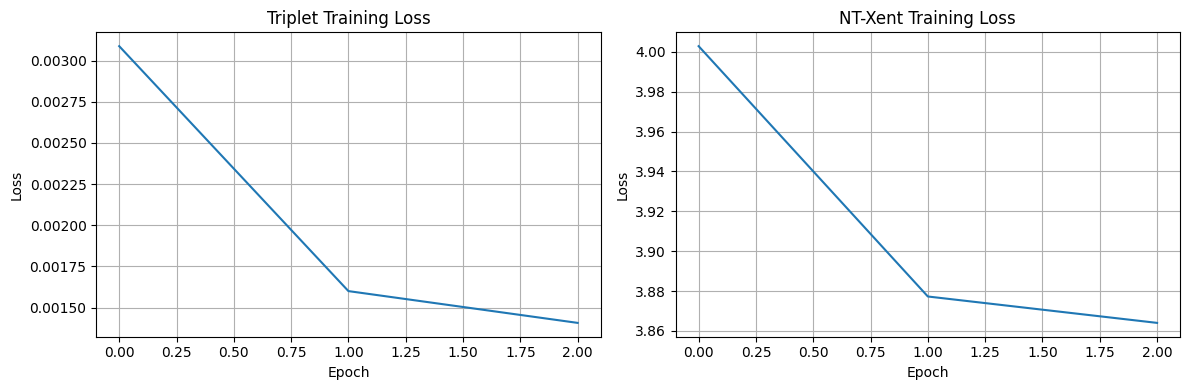

In [ ]:
# Fresh models for each method (no weight sharing)
models = {
    "Triplet": TripletModel(build_simclr_model(), data_augmentation),
    "NT-Xent": SimCLRModel(build_simclr_model(), data_augmentation),
}

histories = {}

for name, custom_model in models.items():
    print(f"\n{'='*40}\nTraining {name} Model\n{'='*40}")

    # ====================================================================================================
    # Solution 4: Compile and Train the Model [15 pts]
    # - Compile the `custom_model` using `keras.optimizers.Adam` with the global `LEARNING_RATE`.
    # - Train the model on `train_dataset` for `EPOCHS` epochs.
    # - Store the returned training `History` object in the dictionary `histories[name]` for later comparison.
    # ====================================================================================================
    custom_model.compile(optimizer=keras.optimizers.Adam(learning_rate=LEARNING_RATE))
    histories[name] = custom_model.fit(train_dataset, epochs=EPOCHS, verbose=1)

# Plot training loss curves
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
model_names = ["Triplet", "NT-Xent"]

for ax, name in zip(axes, model_names):
    ax.plot(histories[name].history["loss"])
    ax.set_title(f"{name} Training Loss")
    ax.set_xlabel("Epoch")
    ax.set_ylabel("Loss")
    ax.grid(True)

plt.tight_layout()
plt.show()

## Part 5: Evaluation & Analysis [20 pts]

**[Course Ref: HW05: Word Embeddings]**  
**[Course Ref: WEEK_06: Siamese Networks]**

Once trained, the model can map any image into a fixed-dimensional embedding (e.g., 128-D). Similar to word embeddings, these image embeddings should place semantically similar images closer together.

In this section, you will evaluate the learned embeddings in two ways:

1. **Qualitative check (Top-K nearest neighbors retrieval)**: given a query image (e.g., dog), retrieve the **top-8** nearest images in embedding space and visually inspect whether the neighbors are semantically similar (often same-class).

2. **Quantitative check (linear probe)**: freeze the encoder and train a **1-layer Dense softmax classifier** on top of the embeddings. Compare test accuracy for Triplet vs NT-Xent.

> Note: The retrieval grid is a human-readable sanity check. Use the linear probe as the main downstream comparison.

**TODO (20 pts total):**

- **5.1 [10 pts]:** Implement the missing retrieval helpers (`compute_embeddings`, `topk_neighbors`) used to build the Top-K retrieval grid.
- **5.2 [10 pts]:** Implement `train_linear_probe(...)` to train and evaluate a linear classifier on frozen embeddings.


### Part 5.1: Top-K nearest neighbors retrieval grid [10 pts]


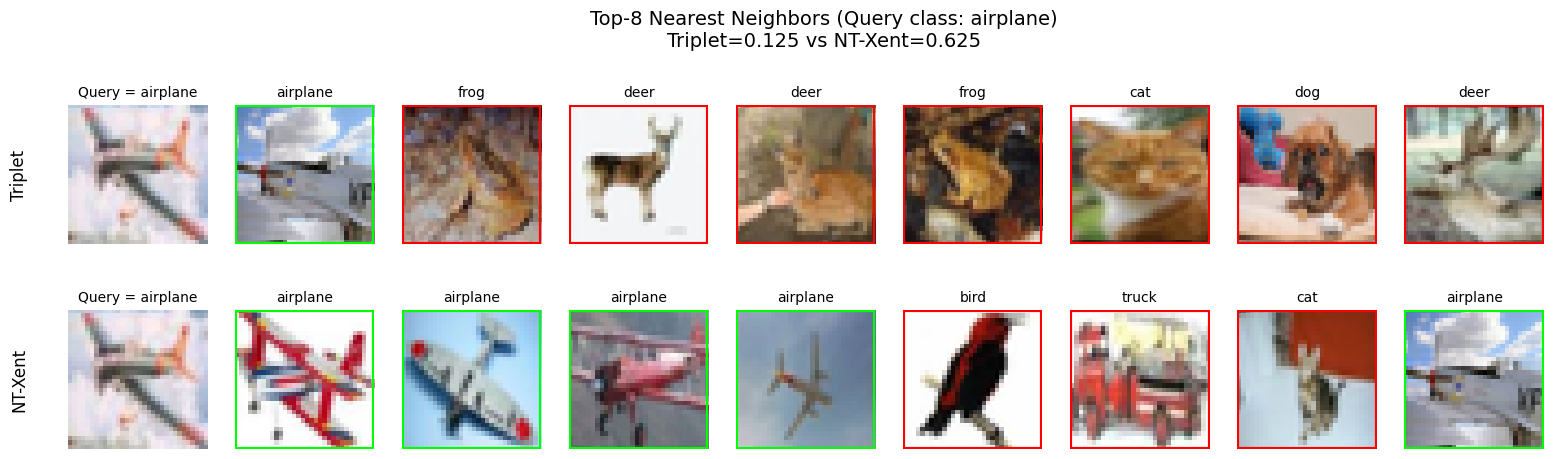

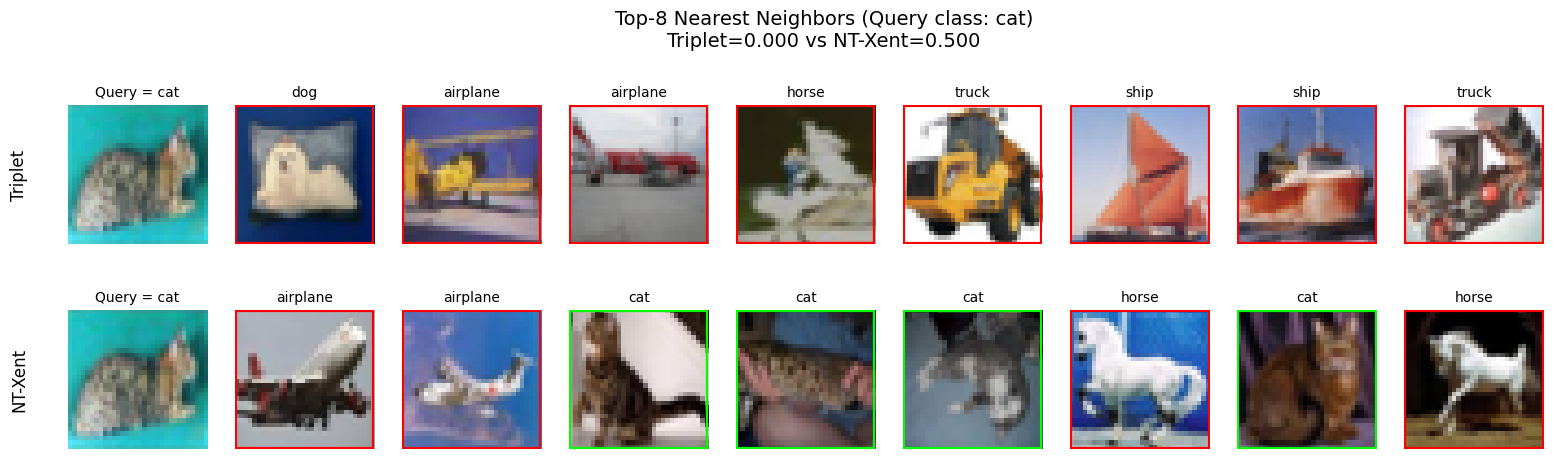

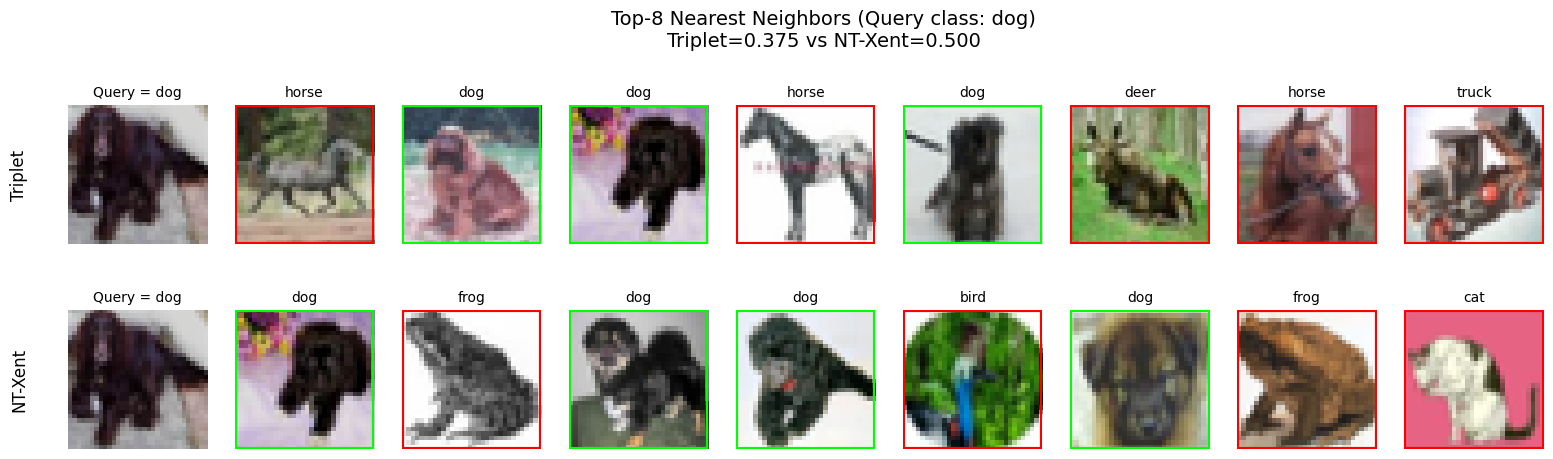

In [ ]:
# Visualization on fixed, representative queries (same subset for both models).

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches

CIFAR10_CLASSES = [
    "airplane",
    "automobile",
    "bird",
    "cat",
    "deer",
    "dog",
    "frog",
    "horse",
    "ship",
    "truck",
]

SUBSET_SIZE = 2000
TOPK = 8

# Fixed subset for fairness/stability (query indices below refer to THIS subset)
rng = np.random.default_rng(123)
subset_idx = rng.choice(len(x_test), size=SUBSET_SIZE, replace=False)
x_sub = x_test[subset_idx]
y_sub = y_test[subset_idx]

# Representative query indices (indices into x_sub / y_sub)
FIXED_QUERY_INDICES = {"airplane": 771, "cat": 514, "dog": 1218}


# =================================================================
# Solution 5.1A: compute_embeddings(custom_model, images) [5 pts]
# 1) encoder.predict -> raw embeddings (N, D)
# 2) cast to float32
# 3) L2-normalize across axis=1
# =================================================================
def l2_normalize_np(x, eps=1e-9):
    return x / (np.linalg.norm(x, axis=1, keepdims=True) + eps)


def compute_embeddings(custom_model, images, batch_size=256):
    # custom_model is TripletModel / SimCLRModel; embeddings come from custom_model.encoder
    z = custom_model.encoder.predict(images, batch_size=batch_size, verbose=0)
    return l2_normalize_np(z.astype(np.float32))


# Precompute embeddings for both methods on the SAME subset
emb_triplet = compute_embeddings(models["Triplet"], x_sub)
emb_ntxent = compute_embeddings(models["NT-Xent"], x_sub)


# =============================================================
# Solution 5.1B: topk_neighbors(qi, emb) [5 pts]
# 1) cosine sims = emb @ emb[qi]  (emb already L2-normalized)
# 2) exclude self: sims[qi] = -inf
# 3) take Top-K indices and sort by descending similarity
# =============================================================
def topk_neighbors(qi, emb, k=TOPK):
    # cosine similarity because emb is L2-normalized
    sims = emb @ emb[qi]
    sims[qi] = -np.inf
    nn = np.argpartition(-sims, k)[:k]
    nn = nn[np.argsort(-sims[nn])]
    return nn, sims[nn]


def plot_two_row_grid(class_name, qi):
    class_id = CIFAR10_CLASSES.index(class_name)
    q_label = CIFAR10_CLASSES[int(y_sub[qi])]
    if q_label != class_name:
        print(f"Warning: qi={qi} label is '{q_label}' (expected '{class_name}').")

    rows = [("Triplet", emb_triplet), ("NT-Xent", emb_ntxent)]
    fig, axes = plt.subplots(2, TOPK + 1, figsize=(2.0 * (TOPK + 1), 5.2))
    fig.subplots_adjust(left=0.08, top=0.82, hspace=0.25)

    per_p = {}

    for r, (row_name, emb) in enumerate(rows):
        nn, sims = topk_neighbors(qi, emb, k=TOPK)
        per_p[row_name] = float(np.mean(y_sub[nn] == class_id))

        # Row label on the left
        axes[r, 0].text(
            -0.35,
            0.5,
            row_name,
            transform=axes[r, 0].transAxes,
            rotation=90,
            va="center",
            ha="center",
            fontsize=12,
        )

        show_idx = [qi] + nn.tolist()
        show_sims = [1.0] + sims.tolist()

        for c, (idx, sim) in enumerate(zip(show_idx, show_sims)):
            ax = axes[r, c]
            ax.imshow(x_sub[idx])
            ax.axis("off")

            lbl = CIFAR10_CLASSES[int(y_sub[idx])]

            # Label on top; mark query explicitly
            if c == 0:
                ax.set_title(f"Query = {lbl}", fontsize=10)
                ax.set_xlabel("Query", fontsize=10)
            else:
                ax.set_title(lbl, fontsize=10)
                ax.set_xlabel(f"{sim:.2f}", fontsize=10)

                # green = correct class, red = incorrect
                color = "lime" if int(y_sub[idx]) == class_id else "red"
                ax.add_patch(
                    patches.Rectangle(
                        (0, 0),
                        1,
                        1,
                        transform=ax.transAxes,
                        fill=False,
                        edgecolor=color,
                        linewidth=3,
                    )
                )

    fig.suptitle(
        f"Top-{TOPK} Nearest Neighbors (Query class: {class_name})\n"
        f"Triplet={per_p['Triplet']:.3f} vs NT-Xent={per_p['NT-Xent']:.3f}",
        fontsize=14,
    )
    plt.show()


for cname, qi in FIXED_QUERY_INDICES.items():
    plot_two_row_grid(cname, int(qi))

### 5.2 Downstream evaluation: Linear Probe (SimCLR-style) [10 pts]

A common way to evaluate representations learned without labels is **linear evaluation**:

1. Freeze the learned embedding model
2. Extract embeddings for labeled data
3. Train a **single linear classifier** on top of the embeddings (no hidden layers)
4. Compare test accuracy

We will run this evaluation for both **Triplet** and **NT-Xent** models and compare accuracies.


In [ ]:
# Linear probe helpers


def extract_embeddings(encoder, x, batch_size=512):
    emb = encoder.predict(x, batch_size=batch_size, verbose=0)
    return emb.astype("float32")


# ==============================================================================
# Solution 5.2: train_linear_probe(train_emb, y_train, test_emb, y_test) [10 pts]
# - Single linear layer Dense(10, softmax) on frozen embeddings
# - Compile: Adam(PROBE_LR), sparse_categorical_crossentropy, accuracy
# - Fit for PROBE_EPOCHS and return test accuracy
# ==============================================================================
def train_linear_probe(train_emb, y_train, test_emb, y_test):
    probe = keras.Sequential(
        [
            layers.Input(shape=(train_emb.shape[1],)),
            layers.Dense(10, activation="softmax"),
        ]
    )
    probe.compile(
        optimizer=keras.optimizers.Adam(learning_rate=PROBE_LR),
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"],
    )
    probe.fit(train_emb, y_train, epochs=PROBE_EPOCHS, batch_size=256, verbose=0)
    loss, acc = probe.evaluate(test_emb, y_test, verbose=0)
    return float(acc)


for name, custom_model in models.items():
    print(f"\n=== Linear Probe for {name} ===")
    train_emb = extract_embeddings(custom_model.encoder, x_probe_train)
    test_emb = extract_embeddings(custom_model.encoder, x_probe_test)
    acc = train_linear_probe(train_emb, y_probe_train, test_emb, y_probe_test)
    print(f"{name} linear-probe test accuracy: {acc:.4f}")


=== Linear Probe for Triplet ===
Triplet linear-probe test accuracy: 0.7576

=== Linear Probe for NT-Xent ===
NT-Xent linear-probe test accuracy: 0.7864


## Part 6. Interpretation and Discussion [5 pts]

Write a short reflection (3-4 sentences) addressing the following points:

SSCL Core Concept: In traditional supervised learning, we use manual labels. How did our self-supervised contrastive learning (SSCL) pipeline manage to learn meaningful representations without them?

Loss Comparison: Briefly compare how Triplet Loss and NT-Xent (SimCLR-style) handle negative samples based on your observations and the SimCLR paper (Section 5.1).

**Model Answer**  
In SSCL, we learn representations without manual labels by applying strong augmentations to create positive pairs (views of the same image) and negative pairs (different images), training the model to maximize agreement between positives. When comparing the losses, Triplet Loss compares one negative at a time using a fixed margin, which often requires complex semi-hard negative mining. In contrast, NT-Xent evaluates the positive pair against all in-batch negatives simultaneously, naturally weighing them by their relative hardness using the temperature parameter.


## Grading Notes (Deductions Only)

- **Part 1: Strong Augmentation [10 pts]**
  - Missing `Resizing` (e.g. 36×36) **−2.5**
  - Missing `RandomCrop` (back to 32×32) **−2.5**
  - Missing `RandomFlip("horizontal")` **−2.5**
  - Missing `RandomColorDistortion` **−2.5**

- **Part 2: Encoder & Projection Head [20 pts]**
  - MobileNetV2 backbone not frozen correctly **−5**
  - `GlobalAveragePooling2D` incorrect **−5**
  - `Dense(256, relu)` incorrect **−5**
  - Final `Dense` output layer incorrect **−5**

- **Part 3: Custom Loss Functions [30 pts]**
  - **3.1 Triplet Loss [10 pts]**
    - `distance_pos` incorrect **−3**
    - `distance_neg` incorrect **−3**
    - `loss` incorrect **−4**

  - **3.2 NT-Xent Loss / SimCLR [20 pts]**
    - `z_a` not normalized correctly **−2**
    - `z_b` not normalized correctly **−2**
    - `logits_ab` incorrect **−2**
    - `logits_ba` incorrect **−2**
    - `batch_size` incorrect **−2**
    - `labels` incorrect **−2**
    - `loss_ab` incorrect **−3**
    - `loss_ba` incorrect **−3**
    - `loss` incorrect **−2**

- **Part 4: Training & Comparison [15 pts]**
  - `custom_model` compiled incorrectly **−5**
  - Model not trained on `train_dataset` for `EPOCHS` **−5**
  - History not stored in `histories` dict **−5**

- **Part 5: Evaluation & Analysis [20 pts]**
  - **5.1 Top-K Retrieval [10 pts]**
    - `compute_embeddings` not using encoder / wrong output shape **−6**
    - Missing L2 normalization **−2**
    - `topk_neighbors` wrong (no self-exclusion or not top-K sorted) **−2**

  - **5.2 Linear Probe [10 pts]**
    - Probe not linear (adds hidden layers) **−5**
    - Output layer / compile wrong (not `Dense(10, softmax)` or wrong loss / metric / optimizer) **−2.5**
    - Doesn’t train / evaluate correctly or doesn’t return accuracy **−2.5**

- **Part 6: Interpretation and Discussion [5 pts]**
  - Missing explanation of how SSCL learns without labels (e.g., using augmentations to create positive/negative pairs) **−2.5**
  - Missing objective comparison of how Triplet vs NT-Xent handle negative samples **−2.5**
